# Case B density-level corridor optimization with particle / density / score diagnostics

Reproduces the spirit of GuidedPID Case B (Fig 5) inside the LQ-GM-PID
density-level framework.  The key advance over the stochastic version:

- **No Monte Carlo in the optimization loop** — corridor adherence is
  evaluated analytically from the exact GMM marginal.
- **Three-layer diagnostic figure** — for each protocol we show a sequence
  of time snapshots with:
    - Row 1: particle samples drawn from the exact marginal GMM,
    - Row 2: density contours (level sets of the exact GMM),
    - Row 3: optimal drift / score vector field.

Scenario:
- S-shaped corridor from origin to a 2-mode GMM target (same geometry
  as GuidedPID Case B).
- Baseline: straight-line guide with uniform isotropic β.
- Optimized: density-level learned transverse offsets ρ_k and transverse
  stiffness β_k^(perp), with anisotropic corridor-aligned β.

In [1]:
from __future__ import annotations

import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch

if "__file__" in globals():
    ROOT = Path(__file__).resolve().parents[1]
else:
    ROOT = Path.cwd().resolve()
    if not (ROOT / "lqgm_pid").exists():
        for parent in [ROOT] + list(ROOT.parents):
            if (parent / "lqgm_pid").exists():
                ROOT = parent
                break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.common import (
    ensure_dir,
    set_seed,
    default_device,
    default_dtype,
    save_metrics_json,
)
from lqgm_pid import (
    GaussianMixture, MatrixPWCProtocol, TimeDomain, LQGMPID,
    gmm_control,
)
from lqgm_pid.density import exact_marginal_gmm

## Configuration

In [2]:
SEED = 42
DEVICE = default_device()
DTYPE = default_dtype()

OUTDIR = ensure_dir(str(ROOT / "results" / "caseB_density"))
FIGDIR = ensure_dir(str(ROOT / "figs"))

# Protocol
K = 10
BC_EPS = 1e-6
TD_EPS = 1e-3

# Optimization
N_ITERS = 300
LR = 3e-2
PRINT_EVERY = 20

# Corridor window
T_CORR_STAR = 0.80

# Weights — see "Objective and regularization" section below for definitions
LAMBDA_CORR = 10.0      # corridor alignment (main objective)
LAMBDA_RHO = 0.10       # guide smoothness + barrier
LAMBDA_BETA = 0.05      # beta smoothness + anchoring

# Corridor geometry — S-shaped, matching GuidedPID Case B spirit
# Entry at origin, exit near (3, 0) with an S-shaped detour
SWING_AMPLITUDE = 0.70
SWING_KAPPA = 6.0

# Stiffnesses
BETA_LONG_FIXED = 0.2           # weak along corridor tangent (not optimized)
BETA_PERP_INIT = 15.0           # moderate transverse — warm start
BETA_PERP_MIN = 2.0             # lower bound: must have *some* confinement
BETA_PERP_MAX = 60.0            # upper bound: prevents numerical stiffness
BETA_PERP_BASELINE = 3.0        # baseline: isotropic at this level (deliberately weak)

# Gaussian corridor kernel widths
OMEGA_LONG = 0.80
OMEGA_PERP = 0.20

# Snapshot times for the main diagnostic figure
SNAPSHOT_TIMES = [0.00, 0.12, 0.25, 0.38, 0.50, 0.62, 0.75, 0.88, 1.00]

# Visualization
XLIM = (-0.6, 3.8)
YLIM = (-1.6, 1.6)
NGRID_DENSITY = 120           # grid for density contours
NGRID_SCORE = 18              # coarse grid for quiver

set_seed(SEED)
print(f"Device: {DEVICE}")

Device: cpu


## Geometry helpers

In [3]:
def _normalize_rows(x, eps=1e-12):
    return x / torch.linalg.norm(x, dim=-1, keepdim=True).clamp_min(eps)

def _fd_tangent(xy):
    dx = torch.zeros_like(xy)
    dx[1:-1] = 0.5 * (xy[2:] - xy[:-2])
    dx[0] = xy[1] - xy[0]
    dx[-1] = xy[-1] - xy[-2]
    return _normalize_rows(dx)

def _match_to_grid(query_t, grid_t):
    return torch.argmin(torch.abs(query_t.unsqueeze(-1) - grid_t.unsqueeze(0)), dim=-1)

## Corridor midline — S-shaped

In [4]:
def make_s_corridor(s_grid, *, x_end=3.0, A=SWING_AMPLITUDE, kappa=SWING_KAPPA):
    """S-shaped corridor from origin to (x_end, 0)."""
    s = s_grid
    x = x_end * s
    # S-shape: tanh transition that swings positive then negative
    y = A * torch.tanh(kappa * (s - 0.30)) - A * torch.tanh(kappa * (s - 0.70))
    # Ensure endpoints are exactly on axis
    y = y - y[0] - (y[-1] - y[0]) * s

    xy = torch.stack([x, y], dim=-1)
    tangent = _fd_tangent(xy)
    normal = torch.stack([-tangent[:, 1], tangent[:, 0]], dim=-1)
    return {"s": s, "xy": xy, "tangent": tangent, "normal": normal}


def sample_corridor_at(corridor, s_k):
    idx = _match_to_grid(s_k, corridor["s"])
    return {k: corridor[k][idx] for k in ["xy", "tangent", "normal"]}

## Target GMM — bimodal, at end of corridor

In [5]:
def make_target(dtype=DTYPE, device=DEVICE):
    weights = torch.tensor([0.5, 0.5], dtype=dtype, device=device)
    means = torch.tensor([[3.0, 0.50], [3.0, -0.50]], dtype=dtype, device=device)
    cov = torch.tensor([[0.06, 0.00], [0.00, 0.05]], dtype=dtype, device=device)
    covs = torch.stack([cov, cov], dim=0)
    return GaussianMixture(weights=weights, means=means, covs=covs)

## Protocol builders

In [6]:
def make_breaks(K, dtype=DTYPE, device=DEVICE):
    return torch.linspace(0.0, 1.0, K + 1, dtype=dtype, device=device)


def s_midpoints(K, dtype=DTYPE, device=DEVICE):
    breaks = make_breaks(K, dtype=dtype, device=device)
    return 0.5 * (breaks[:-1] + breaks[1:])


def build_baseline_protocol(corridor, s_k, breaks):
    """Straight-line guide, isotropic β."""
    geom = sample_corridor_at(corridor, s_k)
    K = s_k.numel()
    # Straight guide: just the corridor midline (no transverse offset)
    nu = geom["xy"].clone()
    beta = BETA_PERP_BASELINE * torch.eye(2, dtype=DTYPE, device=DEVICE).unsqueeze(0).expand(K, -1, -1).clone()
    sigma = torch.zeros(K, 2, 2, dtype=DTYPE, device=DEVICE)
    protocol = MatrixPWCProtocol(breaks=breaks, sigma=sigma, beta=beta, nu=nu,
                                  time_domain=TimeDomain(eps=TD_EPS))
    return protocol, {"nu": nu, "m": geom["xy"], **geom}

## Trainable protocol state

**Optimization variables** (two per PWC interval $k = 1, \ldots, K$):

- $\rho_k \in \mathbb{R}$: transverse offset of the guide from the corridor
  midline. The guide is $\nu_k = m(s_k) + \rho_k \, n(s_k)$ where $m$ is
  the midline and $n$ is the local normal.

- $c_k \in \mathbb{R}$: unconstrained parameter controlling the transverse
  stiffness via a **sigmoid reparameterization**:
  $$\beta_k^{(\perp)} = \beta_{\min}^{(\perp)}
    + (\beta_{\max}^{(\perp)} - \beta_{\min}^{(\perp)})\,\sigma(c_k),$$
  which guarantees $\beta_k^{(\perp)} \in [\beta_{\min}^{(\perp)},
  \beta_{\max}^{(\perp)}]$ for all $c_k$.

The longitudinal stiffness $\beta^{(\parallel)}$ is **fixed** (not optimized).

In [7]:
@dataclass
class TrainableState:
    rho: torch.nn.Parameter      # (K,) transverse guide offset
    c_beta: torch.nn.Parameter   # (K,) unconstrained; β⊥ = β_min + (β_max-β_min)*σ(c)


def c_beta_to_beta_perp(c: torch.Tensor) -> torch.Tensor:
    """Sigmoid reparameterization: c ∈ ℝ → β⊥ ∈ [BETA_PERP_MIN, BETA_PERP_MAX]."""
    return BETA_PERP_MIN + (BETA_PERP_MAX - BETA_PERP_MIN) * torch.sigmoid(c)


def beta_perp_to_c_beta(bp: float) -> float:
    """Inverse: β⊥ → c (for warm-start initialization)."""
    s = (bp - BETA_PERP_MIN) / (BETA_PERP_MAX - BETA_PERP_MIN)
    s = max(1e-6, min(1.0 - 1e-6, s))
    return math.log(s / (1.0 - s))

## Protocol builder

Assembles a `MatrixPWCProtocol` from the trainable state:

- **Guide** $\nu_k = m(s_k) + \rho_k \, n(s_k)$,
- **Shaping matrix** $\beta_k = R_k \,\mathrm{diag}(\beta^{(\parallel)},\,
  \beta_k^{(\perp)})\, R_k^\top$ where $R_k = [q^{(1)}(s_k) \mid q^{(2)}(s_k)]$
  is the local tangent/normal frame.

Both $\rho_k$ and $\beta_k^{(\perp)}$ are differentiable w.r.t. the
optimization variables — the autograd graph is preserved through the
sigmoid and the matrix construction.

In [8]:
def build_trainable_protocol(state, corridor, s_k, breaks):
    """Corridor-aligned anisotropic β with trainable ρ and β_perp."""
    geom = sample_corridor_at(corridor, s_k)
    tangent = geom["tangent"]
    normal = geom["normal"]
    m_k = geom["xy"]
    K = s_k.numel()

    # Guide: midline + transverse offset
    nu = m_k + state.rho[:, None] * normal

    # Build beta keeping autograd alive through c_beta → sigmoid → β_perp.
    beta_list = []
    sigma = torch.zeros(K, 2, 2, dtype=DTYPE, device=DEVICE)
    b_long = torch.tensor(BETA_LONG_FIXED, dtype=DTYPE, device=DEVICE)
    for k in range(K):
        R = torch.stack([tangent[k], normal[k]], dim=-1)           # (2, 2)
        b_perp = c_beta_to_beta_perp(state.c_beta[k])             # bounded, differentiable
        D = torch.diag(torch.stack([b_long, b_perp]))              # (2, 2)
        beta_list.append(R @ D @ R.T)
    beta = torch.stack(beta_list)                                  # (K, 2, 2)

    protocol = MatrixPWCProtocol(breaks=breaks, sigma=sigma, beta=beta, nu=nu,
                                  time_domain=TimeDomain(eps=TD_EPS))
    aux = {"nu": nu, "m": m_k, "tangent": tangent, "normal": normal, "beta": beta}
    return protocol, aux

## Gaussian corridor kernel and density-level loss

### Corridor alignment score

At each protocol midpoint $t_k$, the corridor-alignment score measures
how much of the instantaneous marginal $p_{t_k}(x)$ lies inside the
corridor.  We use a **Gaussian corridor kernel** (eq. (5.12) of the
density appendix):
$$
K_k(x) = \exp\!\bigl(-\tfrac{1}{2}(x - m_k)^\top A_k (x - m_k)\bigr),
\qquad
A_k = Q_k \,\mathrm{diag}(1/\omega_\parallel^2,\, 1/\omega_\perp^2)\, Q_k^\top,
$$
where $m_k$ is the corridor **midline** (fixed, not the guide), $Q_k$ is
the local tangent/normal frame, and $\omega_\parallel, \omega_\perp$ are
the corridor half-widths.  A large $\omega_\parallel$ makes the kernel
forgiving along the corridor; a small $\omega_\perp$ demands tight
transverse confinement.

The alignment score $\mathcal{A}_k = \mathbb{E}_{p_{t_k}}[K_k(x)]$ has
a closed-form Gaussian-mixture evaluation (no sampling needed).

### Corridor loss

$$\mathcal{L}_{\mathrm{corr}}
  = \frac{1}{|\mathcal{K}|}\sum_{k \in \mathcal{K}}
    (1 - \mathcal{A}_k),$$

where $\mathcal{K} = \{k : s_k \le t_*\}$ restricts to the active
corridor window.

In [9]:
def make_kernel_matrix(tangent, normal, omega_long, omega_perp):
    Q = torch.stack([tangent, normal], dim=-1)
    W_inv_sq = torch.diag(torch.tensor(
        [1.0 / omega_long**2, 1.0 / omega_perp**2], dtype=DTYPE, device=DEVICE
    ))
    return Q @ W_inv_sq @ Q.T


def kernel_alignment_single(mu, Sigma, nu, A):
    d = mu.numel()
    I = torch.eye(d, dtype=mu.dtype, device=mu.device)
    M = I + Sigma @ A
    delta = mu - nu
    return torch.exp(-0.5 * delta @ (A @ torch.linalg.solve(M, delta))) / torch.sqrt(torch.det(M))


def exact_alignment(marginal, center, tangent, normal):
    """Alignment of marginal GMM with a Gaussian kernel centered at `center`."""
    A = make_kernel_matrix(tangent, normal, OMEGA_LONG, OMEGA_PERP)
    w = marginal["weights"]
    return sum(w[k] * kernel_alignment_single(marginal["means"][k], marginal["covs"][k], center, A)
               for k in range(w.numel()))


def density_corridor_loss(pid, aux, s_k, *, t_star):
    """Density-level corridor loss: how well the marginal tracks the corridor MIDLINE.

    The kernel is centered at aux["m"][j] (the corridor midline), NOT at
    aux["nu"][j] (the guide).  The guide is the optimization variable that
    shapes the density; the midline is the fixed external target.
    """
    mask = s_k <= t_star
    vals = []
    for j in torch.where(mask)[0].tolist():
        t_q = float(s_k[j].item())
        marg = exact_marginal_gmm(pid, t_q)
        align = exact_alignment(marg, aux["m"][j], aux["tangent"][j], aux["normal"][j])
        vals.append(1.0 - align)
    return torch.stack(vals).mean()

## Regularization terms

### Guide regularization $\mathcal{L}_\rho$

Three components:

1. **First-order smoothness** $\sum_k (\rho_{k+1} - \rho_k)^2$:
   discourages abrupt jumps in the transverse offset.

2. **Second-order smoothness** $\sum_k (\rho_{k+1} - 2\rho_k + \rho_{k-1})^2$:
   penalizes high curvature in the guide centerline.

3. **Soft barrier** $\sum_k \mathrm{softplus}\bigl(\alpha(|\rho_k| - \rho_{\max})\bigr)$:
   prevents the guide from straying too far from the corridor midline.

### Beta regularization $\mathcal{L}_\beta$

Two components (operating on the unconstrained parameter $c_k$):

1. **Smoothness** $\sum_k (c_{k+1} - c_k)^2$: discourages sharp
   stiffness transitions between adjacent intervals.

2. **Anchoring** $\sum_k (c_k - c_k^{(0)})^2$: keeps $\beta_k^{(\perp)}$
   near the warm-start value unless the corridor loss clearly benefits.

Note: since $\beta_k^{(\perp)}$ is already bounded by the sigmoid
reparameterization ($\beta_{\min} \le \beta_k^{(\perp)} \le \beta_{\max}$),
no explicit barrier is needed for beta.

### Total loss

$$\mathcal{L} = \lambda_{\mathrm{corr}}\,\mathcal{L}_{\mathrm{corr}}
  + \lambda_\rho\,\mathcal{L}_\rho
  + \lambda_\beta\,\mathcal{L}_\beta.$$

In [10]:
def rho_regularization(rho, *, alpha_barrier=0.55):
    smooth = ((rho[1:] - rho[:-1])**2).mean()
    if rho.numel() >= 3:
        smooth = smooth + 0.5 * ((rho[2:] - 2*rho[1:-1] + rho[:-2])**2).mean()
    barrier = torch.nn.functional.softplus(15.0 * (rho.abs() - alpha_barrier)).mean() / 15.0
    return smooth + 0.3 * barrier


def beta_regularization(c_beta, c_beta0):
    """Regularize the unconstrained beta parameter c_k."""
    smooth = ((c_beta[1:] - c_beta[:-1])**2).mean()
    anchor = ((c_beta - c_beta0)**2).mean()
    return smooth + 0.5 * anchor


def total_loss(pid, state, aux, s_k, c_beta0):
    Lc = density_corridor_loss(pid, aux, s_k, t_star=T_CORR_STAR)
    Lr = rho_regularization(state.rho)
    Lb = beta_regularization(state.c_beta, c_beta0)
    L = LAMBDA_CORR * Lc + LAMBDA_RHO * Lr + LAMBDA_BETA * Lb
    return L, {"Ltotal": L.item(), "Lcorr": Lc.item(), "Lrho": Lr.item(), "Lbeta": Lb.item()}

## Visualization helpers: density contours, score field, sample scatter

In [11]:
def eval_gmm_density(weights, means, covs, xgrid, ygrid):
    """Evaluate GMM density on a meshgrid.  Returns (ny, nx) array."""
    weights = weights.detach()
    means = means.detach()
    covs = covs.detach()
    nx, ny = xgrid.shape[1], xgrid.shape[0]
    pts = torch.stack([
        torch.as_tensor(xgrid, dtype=DTYPE).reshape(-1),
        torch.as_tensor(ygrid, dtype=DTYPE).reshape(-1),
    ], dim=-1)  # (N, 2)

    log_p = torch.full((pts.shape[0],), -1e30, dtype=DTYPE)
    M = weights.numel()
    for k in range(M):
        diff = pts - means[k].unsqueeze(0)
        L = torch.linalg.cholesky(covs[k])
        z = torch.linalg.solve_triangular(L, diff.T, upper=False).T  # (N, d)
        log_comp = -0.5 * (z**2).sum(-1) - L.diagonal().log().sum() - math.log(2*math.pi)
        log_wk = math.log(max(weights[k].item(), 1e-30)) + log_comp
        log_p = torch.logaddexp(log_p, log_wk)

    return torch.exp(log_p).reshape(ny, nx).numpy()


def eval_score_field(pid, t, xgrid, ygrid):
    """Evaluate u*(t, x) on a meshgrid.  Returns (ux, uy) each (ny, nx)."""
    nx, ny = xgrid.shape[1], xgrid.shape[0]
    pts = torch.stack([
        torch.as_tensor(xgrid, dtype=DTYPE).reshape(-1),
        torch.as_tensor(ygrid, dtype=DTYPE).reshape(-1),
    ], dim=-1)  # (N, 2)

    with torch.no_grad():
        u, _, _ = gmm_control(
            t, pts, pid.x0,
            pid._bwd, pid._fwd,
            pid.target, pid.protocol,
        )
    ux = u[:, 0].reshape(ny, nx).numpy()
    uy = u[:, 1].reshape(ny, nx).numpy()
    return ux, uy


def sample_from_marginal(marginal, n_samples, seed=0):
    """Draw samples from an exact GMM marginal (no simulation)."""
    w = marginal["weights"].detach().cpu()
    mus = marginal["means"].detach().cpu()
    covs = marginal["covs"].detach().cpu()
    gen = torch.Generator().manual_seed(seed)
    ids = torch.multinomial(w, n_samples, replacement=True, generator=gen)
    out = torch.empty(n_samples, mus.shape[1], dtype=DTYPE)
    for k in range(w.numel()):
        idx = torch.where(ids == k)[0]
        if idx.numel() == 0:
            continue
        L = torch.linalg.cholesky(covs[k])
        z = torch.randn(idx.numel(), mus.shape[1], generator=gen, dtype=DTYPE)
        out[idx] = mus[k] + z @ L.T
    return out

## Three-row diagnostic figure builder

In [12]:
@torch.no_grad()
def plot_diagnostic_triplet(
    pid, times, *,
    corridor_xy, guide_nu, guide_tangent, guide_normal,
    target_gmm,
    title_prefix="",
    n_samples=1500,
    figsize=None,
):
    """
    Create a 3-row × len(times)-column figure:
      Row 1: particle samples from exact marginal + corridor + guide
      Row 2: density contours (log scale)
      Row 3: drift/score vector field (quiver)
    """
    ncols = len(times)
    if figsize is None:
        figsize = (2.2 * ncols, 6.5)
    fig, axes = plt.subplots(3, ncols, figsize=figsize, constrained_layout=True)
    if ncols == 1:
        axes = axes[:, None]

    # Meshgrids
    xg = np.linspace(XLIM[0], XLIM[1], NGRID_DENSITY)
    yg = np.linspace(YLIM[0], YLIM[1], NGRID_DENSITY)
    Xd, Yd = np.meshgrid(xg, yg)

    xs = np.linspace(XLIM[0], XLIM[1], NGRID_SCORE)
    ys = np.linspace(YLIM[0], YLIM[1], NGRID_SCORE)
    Xs, Ys = np.meshgrid(xs, ys)

    # Target samples for reference
    tgt_samples = sample_from_marginal(
        {"weights": target_gmm.weights, "means": target_gmm.means, "covs": target_gmm.covs},
        800, seed=999
    ).numpy()

    corr_np = corridor_xy.detach().cpu().numpy()
    nu_np = guide_nu.detach().cpu().numpy()

    for j, t_q in enumerate(times):
        t_eval = float(max(TD_EPS, min(t_q, 1.0 - TD_EPS)))

        # Exact marginal
        marg = exact_marginal_gmm(pid, t_eval)

        # --- Row 0: particles ---
        ax0 = axes[0, j]
        samples = sample_from_marginal(marg, n_samples, seed=SEED + j).numpy()
        ax0.scatter(tgt_samples[:, 0], tgt_samples[:, 1], s=1.5, c="0.78", alpha=0.4, zorder=1)
        ax0.scatter(samples[:, 0], samples[:, 1], s=2.0, c="C0", alpha=0.45, zorder=2)
        ax0.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.4", linewidth=0.8, zorder=3)
        ax0.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", linewidth=1.2, zorder=4)
        ax0.set_title(f"t={t_q:.2f}", fontsize=8)

        # --- Row 1: density contours ---
        ax1 = axes[1, j]
        rho = eval_gmm_density(marg["weights"], marg["means"], marg["covs"], Xd, Yd)
        rho_clip = np.clip(rho, 1e-6, None)
        ax1.contourf(Xd, Yd, rho_clip, levels=15, cmap="Blues", norm=LogNorm(vmin=1e-3, vmax=rho.max()))
        ax1.contour(Xd, Yd, rho_clip, levels=6, colors="0.3", linewidths=0.4,
                    norm=LogNorm(vmin=1e-3, vmax=rho.max()))
        ax1.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.5", linewidth=0.6)
        ax1.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", linewidth=1.0)

        # --- Row 2: score / drift field ---
        ax2 = axes[2, j]
        ux, uy = eval_score_field(pid, t_eval, Xs, Ys)
        mag = np.sqrt(ux**2 + uy**2)
        mag_clip = np.clip(mag, 1e-6, None)
        ax2.quiver(Xs, Ys, ux / mag_clip, uy / mag_clip, mag,
                   cmap="coolwarm", scale=35, width=0.004, headwidth=3.5,
                   alpha=0.85, clim=[0, np.percentile(mag, 95)])
        ax2.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.5", linewidth=0.6)
        ax2.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", linewidth=1.0)

        for row in range(3):
            axes[row, j].set_xlim(XLIM)
            axes[row, j].set_ylim(YLIM)
            axes[row, j].set_aspect("equal", adjustable="box")
            axes[row, j].tick_params(labelsize=5)
            if j > 0:
                axes[row, j].set_yticklabels([])

    # Row labels
    axes[0, 0].set_ylabel("samples", fontsize=8)
    axes[1, 0].set_ylabel("density", fontsize=8)
    axes[2, 0].set_ylabel("drift field", fontsize=8)

    fig.suptitle(title_prefix, fontsize=11, y=1.01)
    return fig

## Build scenario

In [13]:
s_fine = torch.linspace(0, 1, 1001, dtype=DTYPE, device=DEVICE)
corridor = make_s_corridor(s_fine)

target = make_target()

breaks = make_breaks(K)
s_k = s_midpoints(K)

x0 = corridor["xy"][0].clone()
print(f"x0 = {x0}")
print(f"corridor endpoint = {corridor['xy'][-1]}")

x0 = tensor([0., 0.], dtype=torch.float64)
corridor endpoint = tensor([3., 0.], dtype=torch.float64)


## Baseline protocol (straight guide, isotropic β)

In [14]:
protocol_base, aux_base = build_baseline_protocol(corridor, s_k, breaks)
pid_base = LQGMPID(protocol=protocol_base, target=target, x0=x0, bc_eps=BC_EPS)
pid_base.precompute()

L_base = density_corridor_loss(pid_base, aux_base, s_k, t_star=T_CORR_STAR)
print(f"Baseline corridor loss: {L_base.item():.4f}")

Baseline corridor loss: 0.7025


## Warm start and optimization

Initialize $\rho_k = 0$ (guide starts on the midline) and $c_k$ such that
$\beta_k^{(\perp)} = \beta_{\mathrm{init}}^{(\perp)}$ via the inverse
sigmoid.

In [15]:
c_beta0 = torch.full((K,), beta_perp_to_c_beta(BETA_PERP_INIT), dtype=DTYPE, device=DEVICE)

state = TrainableState(
    rho=torch.nn.Parameter(torch.zeros(K, dtype=DTYPE, device=DEVICE)),
    c_beta=torch.nn.Parameter(c_beta0.clone()),
)

optimizer = torch.optim.Adam([state.rho, state.c_beta], lr=LR)

history = []
best = {"Lcorr": float("inf")}

for it in range(1, N_ITERS + 1):
    optimizer.zero_grad()
    protocol, aux = build_trainable_protocol(state, corridor, s_k, breaks)
    pid = LQGMPID(protocol=protocol, target=target, x0=x0, bc_eps=BC_EPS)
    pid.precompute()

    loss, stats = total_loss(pid, state, aux, s_k, c_beta0)
    loss.backward()
    optimizer.step()

    bp_mean = float(c_beta_to_beta_perp(state.c_beta.detach()).mean().item())
    history.append({"iter": it, **stats, "mean_beta_perp": bp_mean})
    if stats["Lcorr"] < best["Lcorr"]:
        best = {"iter": it, "Lcorr": stats["Lcorr"],
                "rho": state.rho.detach().clone(),
                "c_beta": state.c_beta.detach().clone()}

    if it % PRINT_EVERY == 0 or it == 1:
        print(f"iter={it:4d} | L={stats['Ltotal']:.4f} | "
              f"Lcorr={stats['Lcorr']:.4f} | ρ_shift={state.rho.detach().norm():.3f} | "
              f"mean_β⊥={bp_mean:.1f}")

iter=   1 | L=6.3231 | Lcorr=0.6323 | ρ_shift=0.095 | mean_β⊥=15.3
iter=  20 | L=5.5089 | Lcorr=0.5499 | ρ_shift=1.363 | mean_β⊥=21.9
iter=  40 | L=5.1062 | Lcorr=0.5060 | ρ_shift=1.564 | mean_β⊥=28.7
iter=  60 | L=4.9361 | Lcorr=0.4855 | ρ_shift=1.516 | mean_β⊥=34.9
iter=  80 | L=4.8415 | Lcorr=0.4737 | ρ_shift=1.341 | mean_β⊥=39.8
iter= 100 | L=4.7926 | Lcorr=0.4664 | ρ_shift=1.314 | mean_β⊥=43.1
iter= 120 | L=4.7675 | Lcorr=0.4619 | ρ_shift=1.243 | mean_β⊥=45.1
iter= 140 | L=4.7543 | Lcorr=0.4592 | ρ_shift=1.195 | mean_β⊥=46.3
iter= 160 | L=4.7474 | Lcorr=0.4575 | ρ_shift=1.166 | mean_β⊥=47.0
iter= 180 | L=4.7438 | Lcorr=0.4563 | ρ_shift=1.150 | mean_β⊥=47.5
iter= 200 | L=4.7419 | Lcorr=0.4556 | ρ_shift=1.142 | mean_β⊥=47.8
iter= 220 | L=4.7410 | Lcorr=0.4551 | ρ_shift=1.135 | mean_β⊥=48.0
iter= 240 | L=4.7405 | Lcorr=0.4548 | ρ_shift=1.131 | mean_β⊥=48.2
iter= 260 | L=4.7403 | Lcorr=0.4545 | ρ_shift=1.128 | mean_β⊥=48.3
iter= 280 | L=4.7402 | Lcorr=0.4544 | ρ_shift=1.126 | mean_β⊥=

## Restore best and rebuild optimized PID

In [16]:
with torch.no_grad():
    state.rho.copy_(best["rho"])
    state.c_beta.copy_(best["c_beta"])

protocol_opt, aux_opt = build_trainable_protocol(state, corridor, s_k, breaks)
pid_opt = LQGMPID(protocol=protocol_opt, target=target, x0=x0, bc_eps=BC_EPS)
pid_opt.precompute()

L_opt = density_corridor_loss(pid_opt, aux_opt, s_k, t_star=T_CORR_STAR)
print(f"\nBaseline corridor loss: {L_base.item():.4f}")
print(f"Optimized corridor loss: {L_opt.item():.4f}")
print(f"Improvement: {100*(L_base.item() - L_opt.item())/L_base.item():.1f}%")
print(f"Best iteration: {best['iter']}")


Baseline corridor loss: 0.7025
Optimized corridor loss: 0.4542
Improvement: 35.3%
Best iteration: 300


## Figure 1: Loss history

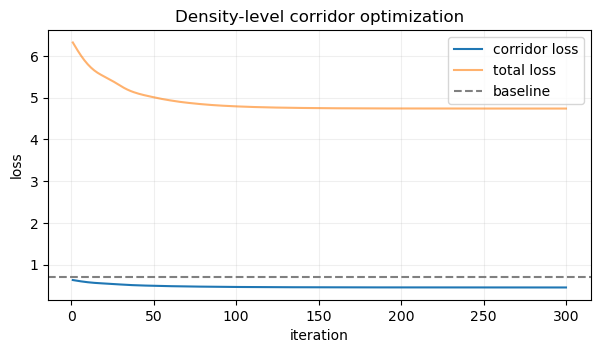

In [17]:
fig0, ax0 = plt.subplots(figsize=(7, 3.5))
ax0.plot([h["iter"] for h in history], [h["Lcorr"] for h in history], label="corridor loss")
ax0.plot([h["iter"] for h in history], [h["Ltotal"] for h in history], label="total loss", alpha=0.6)
ax0.axhline(L_base.item(), ls="--", color="0.5", label="baseline")
ax0.set_xlabel("iteration")
ax0.set_ylabel("loss")
ax0.set_title("Density-level corridor optimization")
ax0.legend()
ax0.grid(alpha=0.2)
fig0.savefig(str(Path(FIGDIR) / "caseB_density_loss.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Figure 2: Optimized protocol parameters

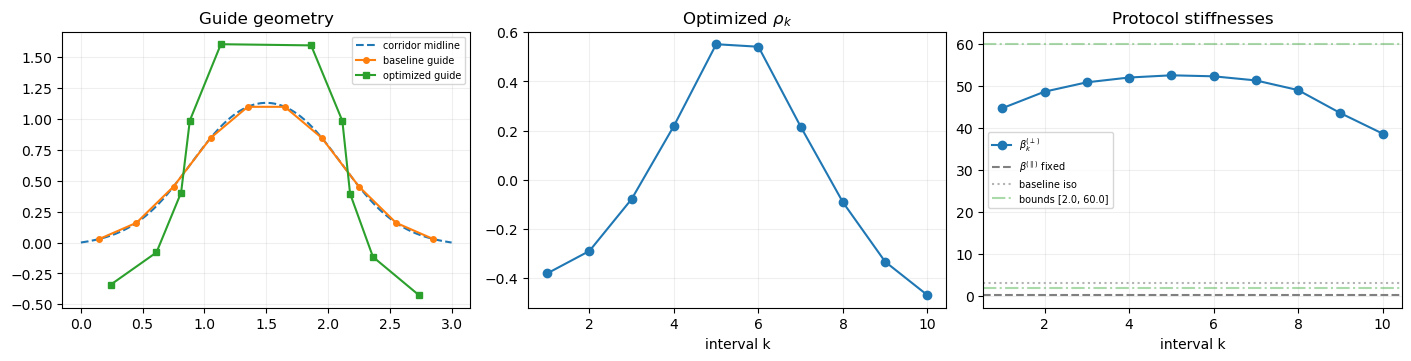

In [18]:
fig1, axes1 = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)

# Corridor + guides
corr_np = corridor["xy"].detach().cpu().numpy()
axes1[0].plot(corr_np[:, 0], corr_np[:, 1], "--", lw=1.5, label="corridor midline")
axes1[0].plot(aux_base["nu"].detach().cpu().numpy()[:, 0],
              aux_base["nu"].detach().cpu().numpy()[:, 1], "o-", ms=4, label="baseline guide")
axes1[0].plot(aux_opt["nu"].detach().cpu().numpy()[:, 0],
              aux_opt["nu"].detach().cpu().numpy()[:, 1], "s-", ms=4, label="optimized guide")
axes1[0].set_title("Guide geometry")
axes1[0].legend(fontsize=7)
axes1[0].set_aspect("equal", adjustable="box")
axes1[0].grid(alpha=0.2)

# rho_k
kk = np.arange(1, K+1)
axes1[1].plot(kk, state.rho.detach().cpu().numpy(), "o-")
axes1[1].set_title(r"Optimized $\rho_k$")
axes1[1].set_xlabel("interval k")
axes1[1].grid(alpha=0.2)

# beta_perp_k
axes1[2].plot(kk, c_beta_to_beta_perp(state.c_beta).detach().cpu().numpy(), "o-", label=r"$\beta_k^{(\perp)}$")
axes1[2].axhline(BETA_LONG_FIXED, ls="--", color="0.5", label=r"$\beta^{(\parallel)}$ fixed")
axes1[2].axhline(BETA_PERP_BASELINE, ls=":", color="0.7", label="baseline iso")
axes1[2].axhline(BETA_PERP_MIN, ls="-.", color="C2", alpha=0.4, label=f"bounds [{BETA_PERP_MIN}, {BETA_PERP_MAX}]")
axes1[2].axhline(BETA_PERP_MAX, ls="-.", color="C2", alpha=0.4)
axes1[2].set_title("Protocol stiffnesses")
axes1[2].set_xlabel("interval k")
axes1[2].legend(fontsize=7)
axes1[2].grid(alpha=0.2)

fig1.savefig(str(Path(FIGDIR) / "caseB_density_params.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Figure 3: Baseline diagnostic triplet (particles / density / score)

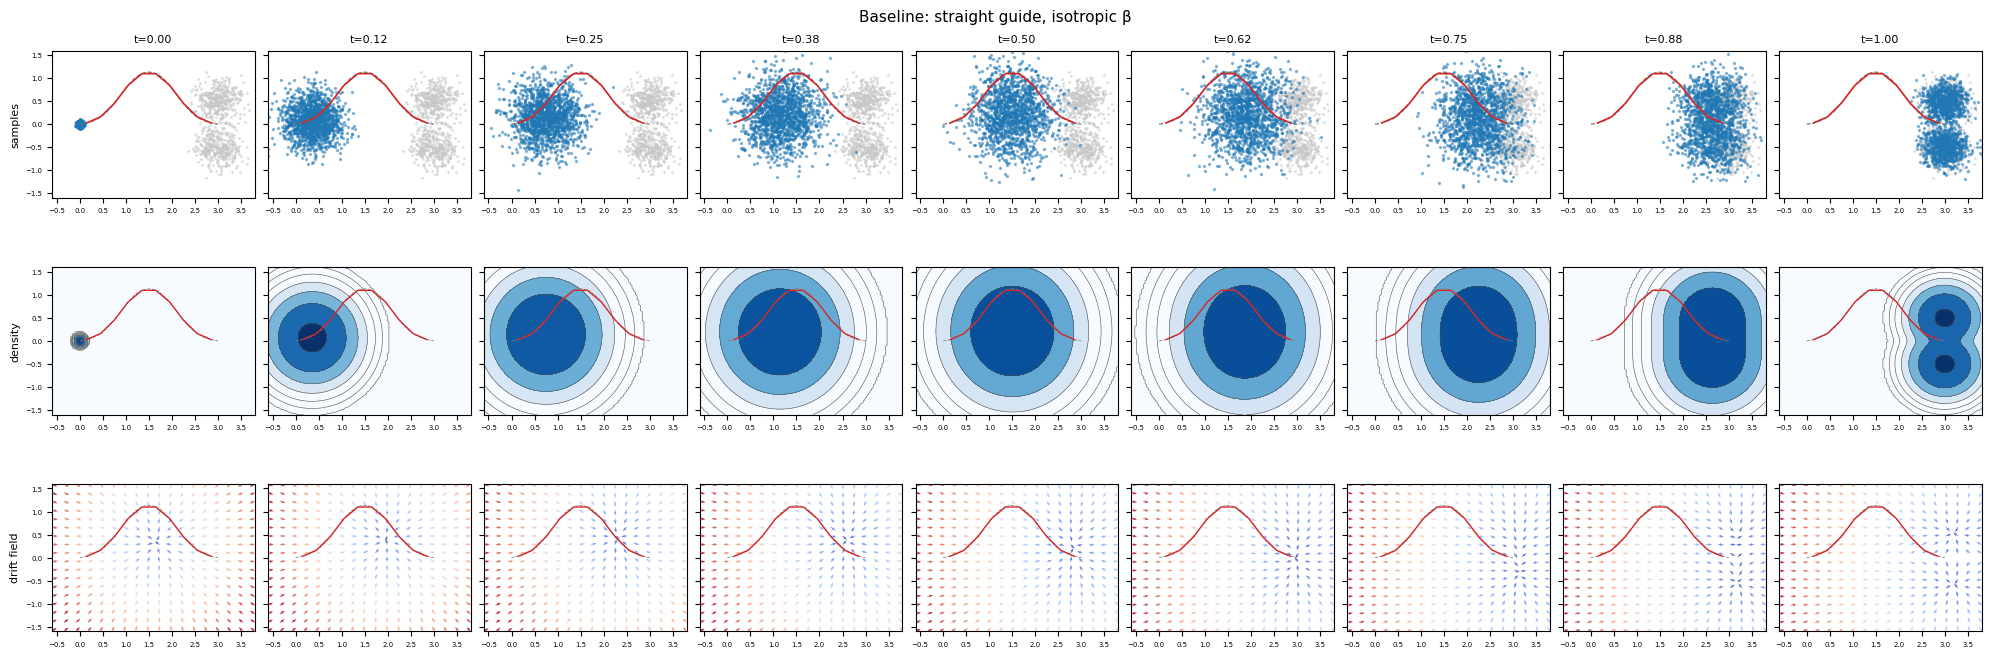

In [19]:
fig_base = plot_diagnostic_triplet(
    pid_base, SNAPSHOT_TIMES,
    corridor_xy=corridor["xy"],
    guide_nu=aux_base["nu"],
    guide_tangent=aux_base["tangent"],
    guide_normal=aux_base["normal"],
    target_gmm=target,
    title_prefix="Baseline: straight guide, isotropic β",
)
fig_base.savefig(str(Path(FIGDIR) / "caseB_density_baseline_triplet.pdf"),
                 dpi=200, bbox_inches="tight")
plt.show()

## Figure 4: Optimized diagnostic triplet (particles / density / score)

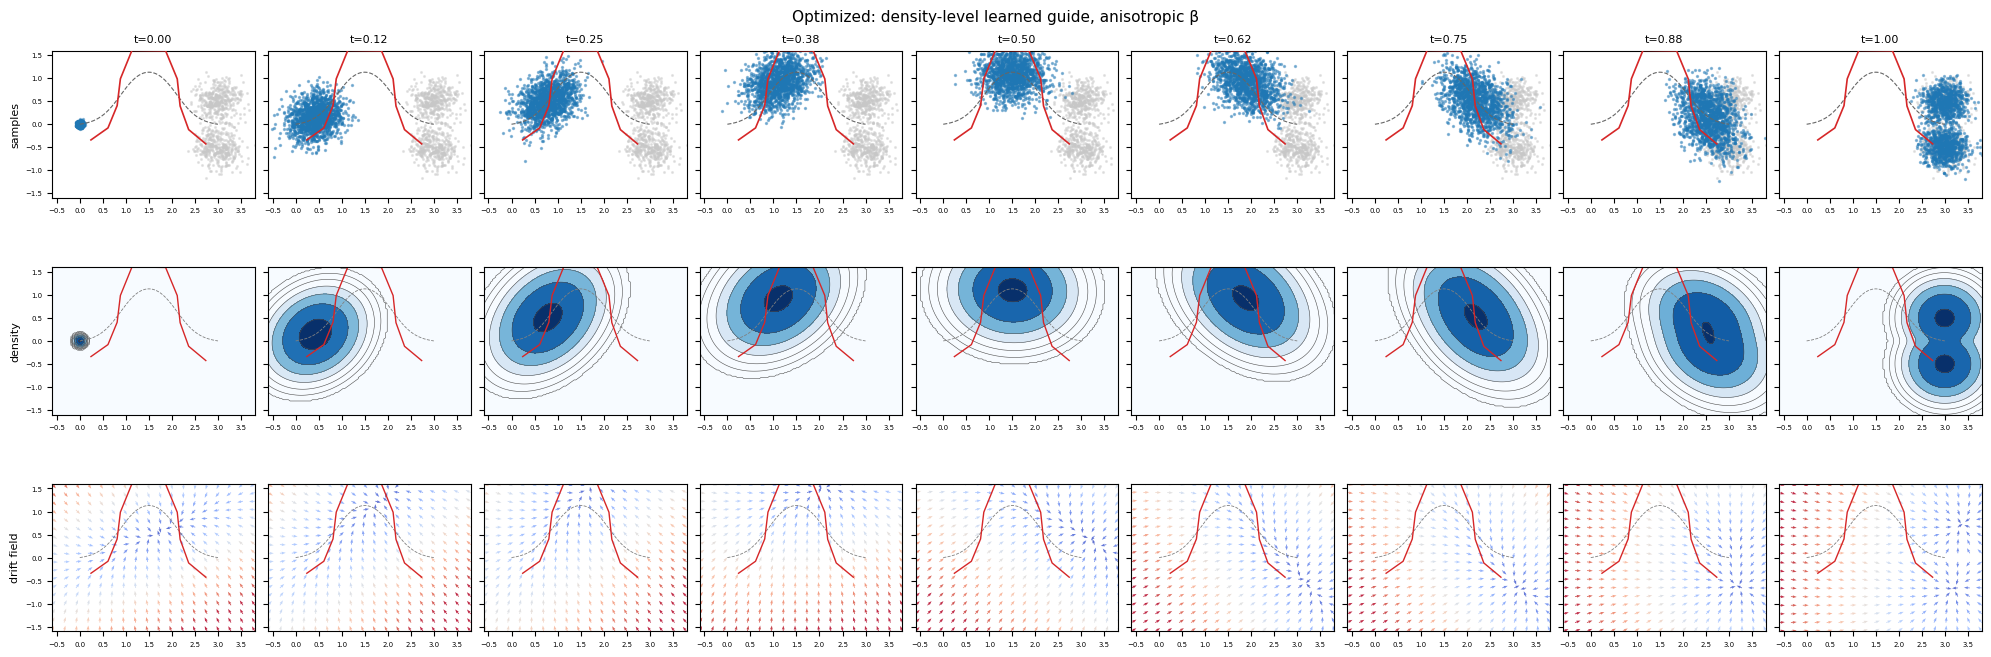

In [20]:
fig_opt = plot_diagnostic_triplet(
    pid_opt, SNAPSHOT_TIMES,
    corridor_xy=corridor["xy"],
    guide_nu=aux_opt["nu"],
    guide_tangent=aux_opt["tangent"],
    guide_normal=aux_opt["normal"],
    target_gmm=target,
    title_prefix="Optimized: density-level learned guide, anisotropic β",
)
fig_opt.savefig(str(Path(FIGDIR) / "caseB_density_optimized_triplet.pdf"),
                dpi=200, bbox_inches="tight")
plt.show()

## Figure 5: Side-by-side comparison at selected times (paper figure)

Compact 2-row figure like GuidedPID Fig 5:
Row 1 = baseline particles, Row 2 = optimized particles.

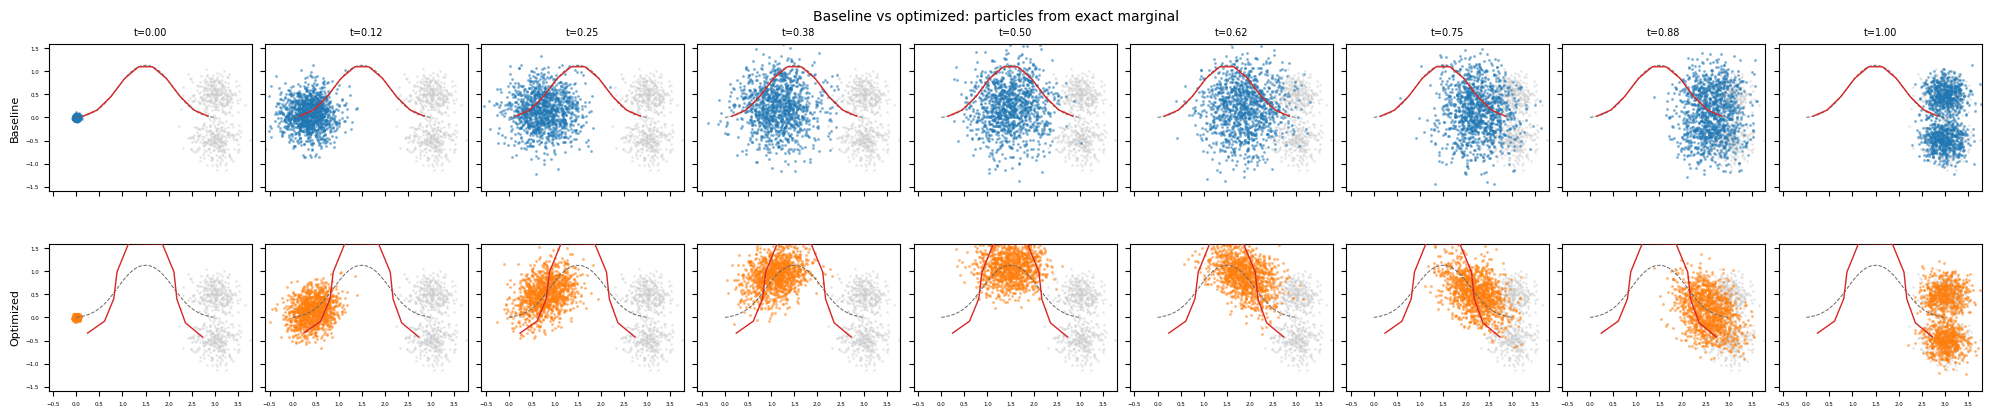

In [22]:
comp_times = [0.00, 0.12, 0.25, 0.38, 0.50, 0.62, 0.75, 0.88, 1.00]
ncols = len(comp_times)
fig5, axes5 = plt.subplots(2, ncols, figsize=(2.2 * ncols, 4.0), constrained_layout=True)

corr_np = corridor["xy"].detach().cpu().numpy()
tgt_samp = sample_from_marginal(
    {"weights": target.weights, "means": target.means, "covs": target.covs},
    600, seed=777
).numpy()

_prev_grad = torch.is_grad_enabled()
torch.set_grad_enabled(False)

for row_idx, (pid_r, aux_r, label) in enumerate([
    (pid_base, aux_base, "Baseline"),
    (pid_opt, aux_opt, "Optimized"),
]):
    nu_np = aux_r["nu"].detach().cpu().numpy()
    for j, t_q in enumerate(comp_times):
        ax = axes5[row_idx, j]
        t_eval = float(max(TD_EPS, min(t_q, 1.0 - TD_EPS)))
        marg = exact_marginal_gmm(pid_r, t_eval)
        samp = sample_from_marginal(marg, 1200, seed=SEED + j + 100*row_idx).numpy()

        ax.scatter(tgt_samp[:, 0], tgt_samp[:, 1], s=1.0, c="0.80", alpha=0.35, zorder=1)
        color = "C0" if row_idx == 0 else "C1"
        ax.scatter(samp[:, 0], samp[:, 1], s=1.5, c=color, alpha=0.4, zorder=2)
        ax.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.4", lw=0.7, zorder=3)
        ax.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", lw=1.0, zorder=4)

        ax.set_xlim(XLIM)
        ax.set_ylim(YLIM)
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(labelsize=4)
        if j > 0:
            ax.set_yticklabels([])
        if row_idx == 0:
            ax.set_title(f"t={t_q:.2f}", fontsize=7)
            ax.set_xticklabels([])

    axes5[row_idx, 0].set_ylabel(label, fontsize=8)

torch.set_grad_enabled(_prev_grad)

fig5.suptitle("Baseline vs optimized: particles from exact marginal", fontsize=10, y=1.02)
fig5.savefig(str(Path(FIGDIR) / "caseB_density_comparison.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Summary metrics

In [23]:
# Terminal diagnostics
with torch.no_grad():
    marg_base_T = exact_marginal_gmm(pid_base, 1.0 - TD_EPS)
    marg_opt_T = exact_marginal_gmm(pid_opt, 1.0 - TD_EPS)

def gmm_mean_cov(marg):
    w = marg["weights"].detach()
    m = marg["means"].detach()
    c = marg["covs"].detach()
    mu = (w.unsqueeze(-1) * m).sum(0)
    S = sum(w[k] * (c[k] + torch.outer(m[k], m[k])) for k in range(w.numel())) - torch.outer(mu, mu)
    return mu, S

mu_base, cov_base = gmm_mean_cov(marg_base_T)
mu_opt, cov_opt = gmm_mean_cov(marg_opt_T)
mu_tgt = (target.weights.unsqueeze(-1) * target.means).sum(0)
cov_tgt = sum(target.weights[k] * (target.covs[k] + torch.outer(target.means[k], target.means[k]))
              for k in range(target.M)) - torch.outer(mu_tgt, mu_tgt)

summary = {
    "baseline_Lcorr": L_base.item(),
    "optimized_Lcorr": L_opt.item(),
    "improvement_pct": 100 * (L_base.item() - L_opt.item()) / L_base.item(),
    "baseline_mean_err": (mu_base - mu_tgt).norm().item(),
    "optimized_mean_err": (mu_opt - mu_tgt).norm().item(),
    "baseline_cov_err": (cov_base - cov_tgt).norm().item(),
    "optimized_cov_err": (cov_opt - cov_tgt).norm().item(),
    "best_iter": best["iter"],
}
for k, v in summary.items():
    print(f"{k:>25s}: {v:.4f}" if isinstance(v, float) else f"{k:>25s}: {v}")

save_metrics_json(str(Path(OUTDIR) / "metrics.json"), summary)

           baseline_Lcorr: 0.7025
          optimized_Lcorr: 0.4542
          improvement_pct: 35.3371
        baseline_mean_err: 0.0031
       optimized_mean_err: 0.0039
         baseline_cov_err: 0.0008
        optimized_cov_err: 0.0025
                best_iter: 300
